In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
from scipy.stats import ttest_ind, ranksums
from decimal import Decimal
import math
import warnings
import statsmodels.api as sm
from statsmodels.formula.api import ols
import pyarrow.feather as feather
import pyxations as pyx

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 700)
sns.set(font_scale=1.1)
pd.options.mode.chained_assignment = None
warnings.filterwarnings("ignore", category=RuntimeWarning)
from matplotlib.cbook import boxplot_stats

In [2]:
def pre_processing_from_feather(
    df_samples: pd.DataFrame,
    type_of_saccade: str,
    baseline_start=-200.0,
    baseline_end=100.0,
    interpolate=False,
    threshold_to_accept_sacc=0.5,
    FILTER=1.5,
    filter_by_block=False,
    selected_block=1,
    savgol_flag=False,
) -> dict:
    meta_cols = ['trial_index', 'typeOfSaccade', 'cueShownAtLeft', 'intraEnd', 'isTutorial']

    # One row per trial (all types), sorted by trial_index — mirrors original row order
    all_trials = (
        df_samples[
            (df_samples['isTutorial'] == False) &
            (df_samples['typeOfSaccade'].notna())
        ][meta_cols]
        .drop_duplicates('trial_index')
        .sort_values('trial_index')
        .reset_index(drop=True)
    )

    # Assign block numbers to ALL trials before type filtering (same logic as original)
    blocks = sum([[i] * 20 for i in range(1, 17)], [])
    all_trials['block'] = blocks

    # Filter by type
    df_saccade = all_trials[all_trials['typeOfSaccade'] == type_of_saccade].copy()

    if filter_by_block:
        df_saccade = df_saccade[df_saccade['block'] == selected_block].copy()

    pro_sacc_errors = 0
    anti_sacc_errors = 0
    ts_xs_ys = []
    pro_sacc_errors_rt = []
    pro_sacc_correct_rt = []
    anti_sacc_errors_rt = []
    anti_sacc_correct_rt = []

    for _, trial_row in df_saccade.iterrows():
        t0 = trial_row['intraEnd']
        t_samps = df_samples[
            df_samples['trial_index'] == trial_row['trial_index']
        ].sort_values('tSample')

        xs = t_samps['X'].to_numpy(dtype=float)
        ys = t_samps['Y'].to_numpy(dtype=float)
        ts = t_samps['tSample'].to_numpy(dtype=float) - t0

        # Interpolate (same as original)
        if interpolate:
            fx = interp1d(ts, xs, kind="linear")
            fy = interp1d(ts, ys, kind="linear")
            samples = int((ts[-1] - (-200)) / 30)
            ts_new = np.linspace(-200, ts[-1], samples)
            xs = fx(ts_new)
            ys = fy(ts_new)
            ts = ts_new

        # 1. Baseline median [-200, 100]
        x_base = np.median(xs[(ts > baseline_start) & (ts < baseline_end)])
        y_base = np.median(ys[(ts > baseline_start) & (ts < baseline_end)])

        # 2. Reference window median [500, 700]
        x_max = np.median(xs[(ts > 500.0) & (ts <= 700.0)])
        y_max = np.median(ys[(ts > 500.0) & (ts <= 700.0)])

        # 3. Normalize
        xs = (xs - x_base) / np.abs(x_base - x_max)
        ys = (ys - y_base) / np.abs(y_base - y_max)

        # 4. Mirror if cue was at left
        if trial_row['cueShownAtLeft'] == True:
            xs = xs * -1

        # 5. Reject noisy trials
        if any(xs > FILTER) or any(xs < -FILTER):
            continue

        # 6. Savitzky-Golay filter (optional)
        if savgol_flag:
            xs = savgol_filter(xs, 5, 2)

        # 7. Detect direction by threshold crossing
        xs_after_baseline = xs[ts > baseline_end]
        ts_after_baseline = ts[ts > baseline_end]

        if type_of_saccade == "prosaccade":
            is_sacc_error_in_trial = np.any(xs_after_baseline < -threshold_to_accept_sacc)
            if is_sacc_error_in_trial:
                pro_sacc_errors += 1
                err_idx = np.where(xs_after_baseline < -threshold_to_accept_sacc)[0][0]
                pro_sacc_errors_rt.append(f"{ts_after_baseline[err_idx]:.2f}")
            else:
                corr_idx = np.where(xs_after_baseline >= threshold_to_accept_sacc)[0]
                if len(corr_idx):
                    pro_sacc_correct_rt.append(f"{ts_after_baseline[corr_idx[0]]:.2f}")

        elif type_of_saccade == "antisaccade":
            is_anti_sacc_error_in_trial = np.any(xs_after_baseline > threshold_to_accept_sacc)
            if is_anti_sacc_error_in_trial:
                anti_sacc_errors += 1
                err_idx = np.where(xs_after_baseline > threshold_to_accept_sacc)[0][0]
                anti_sacc_errors_rt.append(f"{ts_after_baseline[err_idx]:.2f}")
            else:
                corr_idx = np.where(xs_after_baseline <= -threshold_to_accept_sacc)[0]
                if len(corr_idx):
                    anti_sacc_correct_rt.append(f"{ts_after_baseline[corr_idx[0]]:.2f}")

        ts_xs_ys.append((ts, xs, ys))

    try:
        trials_rejected = 100 - (len(ts_xs_ys) / len(df_saccade) * 100)
        pro_saccades_errors_perc = (pro_sacc_errors / len(ts_xs_ys)) * 100
        anti_saccades_errors_perc = (anti_sacc_errors / len(ts_xs_ys)) * 100
    except ZeroDivisionError:
        trials_rejected = 100
        pro_saccades_errors_perc = np.nan
        anti_saccades_errors_perc = np.nan

    return {
        "ts_xs_ys": ts_xs_ys,
        "number_of_trials_remained": len(ts_xs_ys),
        "pro_sacc_errors": pro_sacc_errors,
        "pro_sacc_errors_perc": pro_saccades_errors_perc,
        "anti_sacc_errors": anti_sacc_errors,
        "anti_sacc_errors_perc": anti_saccades_errors_perc,
        "trials_rejected": trials_rejected,
        "pro_sacc_errors_rt": pro_sacc_errors_rt,
        "pro_sacc_correct_rt": pro_sacc_correct_rt,
        "anti_sacc_errors_rt": anti_sacc_errors_rt,
        "anti_sacc_correct_rt": anti_sacc_correct_rt,
    }


def one_subject(df, suj_number, type_of_saccade):
    fig, axs = plt.subplots(
        3, 1, height_ratios=[1, 4, 1], sharex=True, constrained_layout=True
    )
    suj_number = str(suj_number)
    df = df.query("subject == @suj_number")
    for i in df.query("subject == @suj_number")[type_of_saccade].iloc[0]:
        ts, xs, ys = i[0], i[1], i[2]
        axs[1].plot(ts, xs)
        axs[1].axhline(y=0.5, color="k", linestyle="-")
        axs[1].axhline(y=-0.5, color="k", linestyle="-")
        axs[1].axvline(x=0, color="k", linestyle="-")
        axs[1].set_ylabel("x coordinate predictions")
        axs[1].set_xticks(np.arange(-200, 1000, step=100))
        axs[1].set_xlim(-200, 700)
        axs[1].set_ylim(-2, 2)
    if type_of_saccade == "prosaccade":
        data_error = [float(i) for i in df["pro_sacc_errors_rt"].iloc[0]]
        data_correct = [float(i) for i in df["pro_sacc_correct_rt"].iloc[0]]
        sns.kdeplot(data_error, ax=axs[2])
        sns.rugplot(data_error, ax=axs[2], height=0.1)
        sns.kdeplot(data_correct, ax=axs[0])
        sns.rugplot(data_correct, ax=axs[0], height=0.1)
        axs[2].set_xlim([-200, 700])
        axs[2].invert_yaxis()
        axs[0].set_xlim([-200, 700])
    else:
        data_error = [float(i) for i in df["anti_sacc_errors_rt"].iloc[0]]
        data_correct = [float(i) for i in df["anti_sacc_correct_rt"].iloc[0]]
        sns.kdeplot(data_error, ax=axs[0])
        sns.rugplot(data_error, ax=axs[0], height=0.1)
        sns.kdeplot(data_correct, ax=axs[2])
        sns.rugplot(data_correct, ax=axs[2], height=0.1)
        axs[0].set_xlim([-200, 700])
        axs[2].set_xlim([-200, 700])
        axs[2].invert_yaxis()
    plt.suptitle(f"{type_of_saccade}")
    fig.align_ylabels(axs[:])
    fig.supxlabel("time (ms)")
    plt.show()

def calculate_distance(x_positions):
    distances = np.diff(x_positions)
    distance = np.sum(np.sqrt(distances ** 2))
    return distance

In [3]:
RAW_DATA   = Path('./raw_data')
OUTPUT_DIR = Path('.')
BIDS_NAME  = 'antisaccades_bids'
SCREEN_W, SCREEN_H = 1366, 768

BEHAVIORAL_COLS = [
    'typeOfSaccade', 'cueShownAtLeft',
    'itiEnd', 'fixEnd', 'intraEnd', 'visualEnd', 'responseEnd',
    'viewportWidth', 'isTutorial',
]

bids_path = pyx.dataset_to_bids(
    OUTPUT_DIR, RAW_DATA, BIDS_NAME, format_name='webgazer'
)

pyx.compute_derivatives_for_dataset(
    bids_path,
    dataset_format='webgazer',
    detection_algorithm='remodnav',
    overwrite=True,
    screen_height=SCREEN_H,
    screen_width=SCREEN_W,
    behavioral_columns=BEHAVIORAL_COLS,
)

derivatives_path = bids_path.with_name(bids_path.name + '_derivatives')
print(f'Derivatives: {derivatives_path}')


Running eye movements detection for None eye...
Running eye movements detection for None eye...

Running eye movements detection for None eye...


Running eye movements detection for None eye...
Dropping saccades with average vel > 1000.0 deg/s, and fixations with amplitude > 1.5 deg
Kept 106 out of 410 fixations
Kept 410 out of 410 saccades
Finding previous and next saccades


100%|██████████| 106/106 [00:00<00:00, 2634.27it/s]



Kept 97 fixations with previous saccade
Computing average pupil size, and x and y position


100%|██████████| 97/97 [00:00<00:00, 2502.18it/s]


Skipping preprocessing: not enough parameters for trial segmentation (need (start_times & end_times) or (start_msgs & durations) or (start_msgs & end_msgs)).
Dropping saccades with average vel > 1000.0 deg/s, and fixations with amplitude > 1.5 deg
Kept 141 out of 520 fixations
Kept 529 out of 529 saccades
Finding previous and next saccades


...

Skipping preprocessing: not enough parameters for trial segmentation (need (start_times & end_times) or (start_msgs & durations) or (start_msgs & end_msgs)).
Dropping saccades with average vel > 1000.0 deg/s, and fixations with amplitude > 1.5 deg
Kept 253 out of 670 fixations
Kept 707 out of 707 saccades
Finding previous and next saccades


100%|██████████| 253/253 [00:00<00:00, 1771.87it/s]



Kept 244 fixations with previous saccade
Computing average pupil size, and x and y position


100%|██████████| 244/244 [00:00<00:00, 2589.55it/s]


Skipping preprocessing: not enough parameters for trial segmentation (need (start_times & end_times) or (start_msgs & durations) or (start_msgs & end_msgs)).
Derivatives: antisaccades_bids_derivatives


### Load all files and **separate in blocks**

In [4]:
all_dfs = []

print("processing ...")
for ses_dir in sorted((derivatives_path / 'sub-0001').iterdir()):
    samples_file = ses_dir / 'samples.feather'
    if not samples_file.exists():
        continue

    suj = ses_dir.name[4:]  # "ses-100" -> "100"
    df_samples = feather.read_feather(samples_file)

    subjects = []
    prosaccade_trials_remained = []
    antisaccade_trials_remained = []
    pro_saccades = []
    anti_saccades = []
    pro_saccades_errors = []
    pro_saccades_errors_perc = []
    anti_saccades_errors = []
    anti_saccades_errors_perc = []
    trials_rejected_prosaccade = []
    trials_rejected_antisaccade = []
    pro_sacc_errors_rt = []
    pro_sacc_correct_rt = []
    anti_sacc_errors_rt = []
    anti_sacc_correct_rt = []
    block_number = []

    print(suj)

    for block in range(1, 17):
        anti_saccade_dict = pre_processing_from_feather(
            df_samples,
            type_of_saccade="antisaccade",
            interpolate=True,
            filter_by_block=True,
            selected_block=block,
        )
        pro_saccade_dict = pre_processing_from_feather(
            df_samples,
            type_of_saccade="prosaccade",
            interpolate=True,
            filter_by_block=True,
            selected_block=block,
        )
        subjects.append(suj)
        pro_saccades.append(pro_saccade_dict["ts_xs_ys"])
        anti_saccades.append(anti_saccade_dict["ts_xs_ys"])
        prosaccade_trials_remained.append(pro_saccade_dict["number_of_trials_remained"])
        antisaccade_trials_remained.append(anti_saccade_dict["number_of_trials_remained"])
        pro_saccades_errors.append(pro_saccade_dict["pro_sacc_errors"])
        pro_saccades_errors_perc.append(pro_saccade_dict["pro_sacc_errors_perc"])
        anti_saccades_errors.append(anti_saccade_dict["anti_sacc_errors"])
        anti_saccades_errors_perc.append(anti_saccade_dict["anti_sacc_errors_perc"])
        trials_rejected_prosaccade.append(pro_saccade_dict["trials_rejected"])
        trials_rejected_antisaccade.append(anti_saccade_dict["trials_rejected"])
        pro_sacc_errors_rt.append(pro_saccade_dict["pro_sacc_errors_rt"])
        pro_sacc_correct_rt.append(pro_saccade_dict["pro_sacc_correct_rt"])
        anti_sacc_errors_rt.append(anti_saccade_dict["anti_sacc_errors_rt"])
        anti_sacc_correct_rt.append(anti_saccade_dict["anti_sacc_correct_rt"])
        block_number.append(block)

    _df = pd.DataFrame({
        "subject":                              subjects,
        "prosaccade":                           pro_saccades,
        "antisaccade":                          anti_saccades,
        "prosaccade_errors":                    pro_saccades_errors,
        "antisaccade_errors":                   anti_saccades_errors,
        "delta_errors":                         np.array(anti_saccades_errors) - np.array(pro_saccades_errors),
        "trials_rejected_antisaccade_percentage": trials_rejected_antisaccade,
        "trials_rejected_prosaccade_percentage":  trials_rejected_prosaccade,
        "pro_sacc_errors_rt":                   pro_sacc_errors_rt,
        "pro_sacc_correct_rt":                  pro_sacc_correct_rt,
        "anti_sacc_errors_rt":                  anti_sacc_errors_rt,
        "anti_sacc_correct_rt":                 anti_sacc_correct_rt,
        "prosaccade_errors_perc":               pro_saccades_errors_perc,
        "antisaccade_errors_perc":              anti_saccades_errors_perc,
        "prosaccade_trials_remained":           prosaccade_trials_remained,
        "antisaccade_trials_remained":          antisaccade_trials_remained,
        "block":                                block_number,
    })

    _df["pro_sacc_errors_rt_median"] = _df["pro_sacc_errors_rt"].apply(
        lambda x: np.median([float(i) for i in x]) if x else np.nan
    )
    _df["pro_sacc_correct_rt_median"] = _df["pro_sacc_correct_rt"].apply(
        lambda x: np.median([float(i) for i in x]) if x else np.nan
    )
    _df["anti_sacc_errors_rt_median"] = _df["anti_sacc_errors_rt"].apply(
        lambda x: np.median([float(i) for i in x]) if x else np.nan
    )
    _df["anti_sacc_correct_rt_median"] = _df["anti_sacc_correct_rt"].apply(
        lambda x: np.median([float(i) for i in x]) if x else np.nan
    )

    all_dfs.append(_df)

df_all_blocks = pd.concat(all_dfs)
print("\ndf_all_blocks ready ✅")

processing ...
100
101
102
103
104
105
107
109
110
111
112
113
114
115
117
118
119
123
124
125
126
127
91
92
98
99

df_all_blocks ready ✅


### Filtering blocks

In [5]:
# Constants
MAX_NUMBER_INCORRECTS_BY_BLOCK = (
    10  # Esto implica que en un bloque hizo al menos el 50% mal
)
FIRST_BLOCK = 2
LAST_BLOCK = 8

# Filter
df_blocks_filtered = (
    df_all_blocks.query(
        "prosaccade_errors < @MAX_NUMBER_INCORRECTS_BY_BLOCK and antisaccade_errors < @MAX_NUMBER_INCORRECTS_BY_BLOCK and @FIRST_BLOCK <= block <= @LAST_BLOCK"
    )  # Con la mitad de los bloques
    .groupby("subject")
    .agg(
        {
            "prosaccade": list,
            "antisaccade": list,
            "prosaccade_errors": "sum",
            "antisaccade_errors": "sum",
            "prosaccade_trials_remained": "sum",
            "antisaccade_trials_remained": "sum",
            "pro_sacc_errors_rt": "sum",
            "pro_sacc_correct_rt": "sum",
            "anti_sacc_errors_rt": "sum",
            "anti_sacc_correct_rt": "sum",
            "pro_sacc_errors_rt_median": np.nanmean,
            "anti_sacc_errors_rt_median": np.nanmean,
            "pro_sacc_correct_rt_median": np.nanmean,
            "anti_sacc_correct_rt_median": np.nanmean,
            "block": lambda x: x.nunique(),
        }
    )
)

df_blocks_filtered = df_blocks_filtered.rename({"block": "remained_blocks"}, axis=1)
df_blocks_filtered["max_number_incorrect_by_block"] = MAX_NUMBER_INCORRECTS_BY_BLOCK
df_blocks_filtered.insert(
    2,
    "delta_errors",
    df_blocks_filtered["antisaccade_errors"] - df_blocks_filtered["prosaccade_errors"],
)


# Percentage
df_blocks_filtered["prosaccade_errors_perc"] = (
    df_blocks_filtered["prosaccade_errors"]
    / df_blocks_filtered["prosaccade_trials_remained"]
) * 100


df_blocks_filtered["antisaccade_errors_perc"] = (
    df_blocks_filtered["antisaccade_errors"]
    / df_blocks_filtered["antisaccade_trials_remained"]
) * 100

print("df_blocks_filtered ready ✅")

df_blocks_filtered ready ✅


### Plot stuff

0.0607
N=26, blocks=7
Cantidad de bloques filtrados: 237


/tmp/ipykernel_27391/3608284975.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)


,prosaccade_errors_perc,antisaccade_errors_perc
count,26.000000,26.000000
mean,3.858359,5.987505
std,2.636911,3.914832
min,0.000000,0.000000
25%,1.815789,2.931489
50%,3.572568,5.337129
75%,5.406699,9.410495
max,8.620690,13.157895


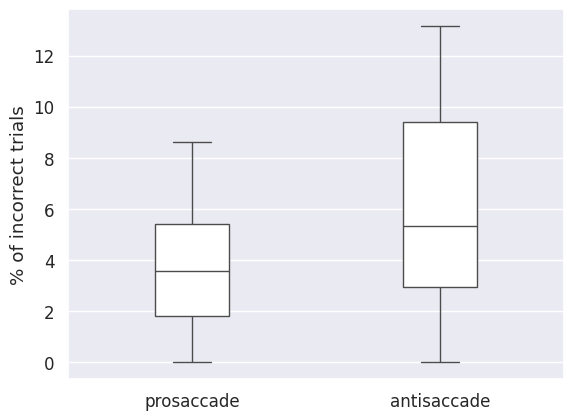

In [6]:
# Plot errors
ax = sns.boxplot(
    data=df_blocks_filtered[["prosaccade_errors_perc", "antisaccade_errors_perc"]],
    width=0.3,
)
ax.set_ylabel("% of incorrect trials")
labels = [item.get_text() for item in ax.get_xticklabels()]
labels = ['prosaccade', 'antisaccade']
ax.set_xticklabels(labels)

boxes = ax.patches

for i, box in enumerate(boxes):
    box.set_facecolor("w")


p_value = round((
    ranksums(
        df_blocks_filtered["prosaccade_errors_perc"],
        df_blocks_filtered["antisaccade_errors_perc"],
    )[1]
), 4)

print(p_value)
print(f"N={len(df_blocks_filtered)}, blocks={df_blocks_filtered['remained_blocks'].max()}")

print(f"Cantidad de bloques filtrados: {(len(df_blocks_filtered['remained_blocks']) * 16)  - df_blocks_filtered['remained_blocks'].sum()}")

df_blocks_filtered.describe()[["prosaccade_errors_perc", "antisaccade_errors_perc"]]

In [7]:
print("means:") 
print(df_blocks_filtered.describe()[["prosaccade_errors_perc", "antisaccade_errors_perc"]].loc['mean',:].round(1), end='\n\n')
print("std:") 
print(df_blocks_filtered.describe()[["prosaccade_errors_perc", "antisaccade_errors_perc"]].loc['std',:].round(1), end='\n\n')
print("median:") 
print(df_blocks_filtered.describe()[["prosaccade_errors_perc", "antisaccade_errors_perc"]].loc['50%',:].round(1), end='\n\n')
print("25%:",) 
print(df_blocks_filtered.describe()[["prosaccade_errors_perc", "antisaccade_errors_perc"]].loc['25%',:].round(1), end='\n\n')
print("75%:") 
print(df_blocks_filtered.describe()[["prosaccade_errors_perc", "antisaccade_errors_perc"]].loc['75%',:].round(1), end='\n\n')

means:
prosaccade_errors_perc     3.9
antisaccade_errors_perc    6.0
Name: mean, dtype: float64

std:
prosaccade_errors_perc     2.6
antisaccade_errors_perc    3.9
Name: std, dtype: float64

median:
prosaccade_errors_perc     3.6
antisaccade_errors_perc    5.3
Name: 50%, dtype: float64

25%:
prosaccade_errors_perc     1.8
antisaccade_errors_perc    2.9
Name: 25%, dtype: float64

75%:
prosaccade_errors_perc     5.4
antisaccade_errors_perc    9.4
Name: 75%, dtype: float64



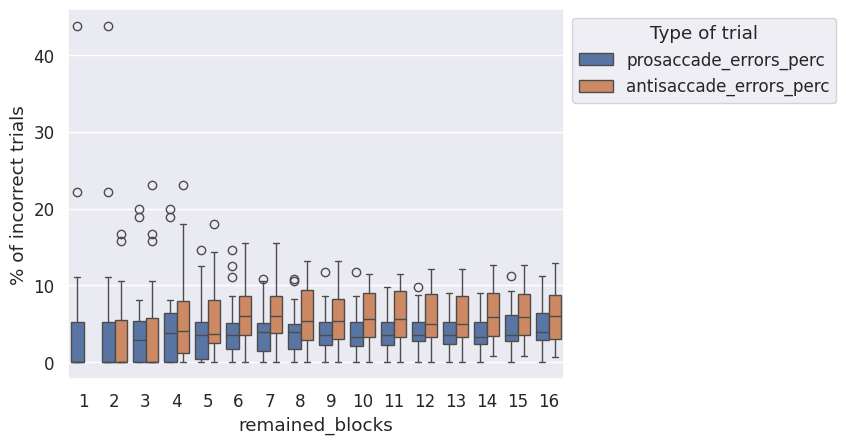

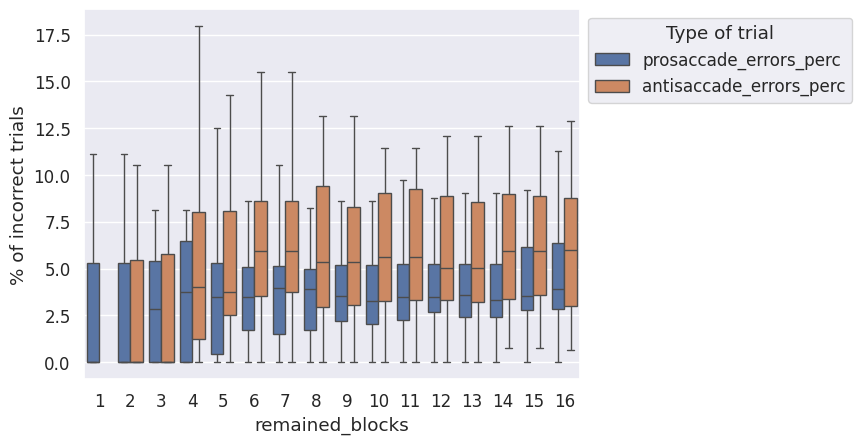

In [8]:
# Incorrectos por bloque
all_dfs = []
for last_block in range(1, 17):
    FIRST_BLOCK = 1
    LAST_BLOCK = last_block

    _df_blocks_filtered = (
        df_all_blocks.query(
            "prosaccade_errors < @MAX_NUMBER_INCORRECTS_BY_BLOCK and antisaccade_errors < @MAX_NUMBER_INCORRECTS_BY_BLOCK and @FIRST_BLOCK <= block <= @LAST_BLOCK"
        )
        .groupby("subject")
        .agg(
            {
                "prosaccade_errors": "sum",
                "antisaccade_errors": "sum",
                "prosaccade_trials_remained": "sum",
                "antisaccade_trials_remained": "sum",
                "pro_sacc_errors_rt": "sum",
                "pro_sacc_correct_rt": "sum",
                "anti_sacc_errors_rt": "sum",
                "anti_sacc_correct_rt": "sum",
                "pro_sacc_errors_rt_median": np.nanmean,
                "anti_sacc_errors_rt_median": np.nanmean,
                "pro_sacc_correct_rt_median": np.nanmean,
                "anti_sacc_correct_rt_median": np.nanmean,
                "block": lambda x: x.nunique(),
            }
        )
    )

    _df_blocks_filtered = _df_blocks_filtered.rename({"block": "remained_blocks"}, axis=1)

    _df_blocks_filtered["prosaccade_errors_perc"] = (
        _df_blocks_filtered["prosaccade_errors"]
        / _df_blocks_filtered["prosaccade_trials_remained"]
    ) * 100

    _df_blocks_filtered["antisaccade_errors_perc"] = (
        _df_blocks_filtered["antisaccade_errors"]
        / _df_blocks_filtered["antisaccade_trials_remained"]
    ) * 100
    all_dfs.append(_df_blocks_filtered)

all_dataframes = pd.concat(all_dfs)

ax = sns.boxplot(
    data=all_dataframes.melt(id_vars=['remained_blocks'], value_vars=['prosaccade_errors_perc', 'antisaccade_errors_perc'],
                 var_name='Type of trial', value_name='% of incorrect trials'),
    x='remained_blocks',
    y='% of incorrect trials',
    hue='Type of trial',
    showfliers=True
)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.show()

ax = sns.boxplot(
    data=all_dataframes.melt(id_vars=['remained_blocks'], value_vars=['prosaccade_errors_perc', 'antisaccade_errors_perc'],
                 var_name='Type of trial', value_name='% of incorrect trials'),
    x='remained_blocks',
    y='% of incorrect trials',
    hue='Type of trial',
    showfliers=False
)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.show()

/tmp/ipykernel_27391/2884423160.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


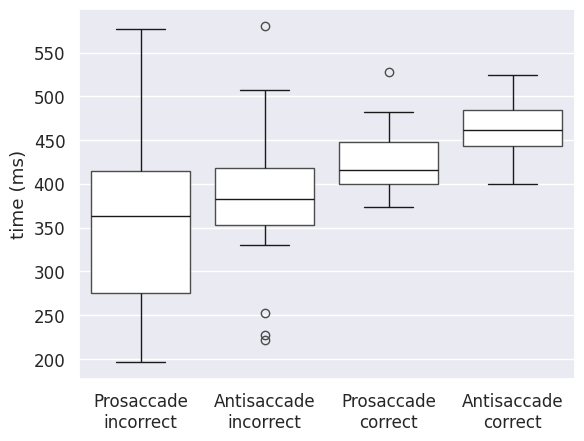

,delta_errors,prosaccade_errors,antisaccade_errors,prosaccade_trials_remained,antisaccade_trials_remained,pro_sacc_errors_rt_median,anti_sacc_errors_rt_median,pro_sacc_correct_rt_median,anti_sacc_correct_rt_median,remained_blocks,max_number_incorrect_by_block,prosaccade_errors_perc,antisaccade_errors_perc
count,26.000000,26.000000,26.000000,26.000000,26.000000,22.000000,24.000000,26.000000,26.000000,26.000000,26.0,26.000000,26.000000
mean,2.153846,2.153846,4.307692,54.423077,72.076923,362.386326,383.460538,424.574231,463.295785,6.884615,10.0,3.858359,5.987505
std,2.962328,1.541228,2.825162,5.615501,8.676050,110.981610,80.966569,35.570188,30.150567,0.325813,0.0,2.636911,3.914832
min,-4.000000,0.000000,0.000000,39.000000,45.000000,196.265000,222.180000,374.085000,399.388750,6.000000,10.0,0.000000,0.000000
25%,0.000000,1.000000,2.000000,52.750000,69.500000,275.068750,352.956563,400.060000,443.581875,7.000000,10.0,1.815789,2.931489
50%,2.000000,2.000000,4.000000,57.000000,75.500000,363.222500,382.520833,415.817500,461.001875,7.000000,10.0,3.572568,5.337129
75%,4.000000,3.000000,6.000000,58.000000,78.000000,414.385000,418.386250,448.299583,483.926250,7.000000,10.0,5.406699,9.410495
max,8.000000,5.000000,10.000000,59.000000,80.000000,577.005000,580.055000,527.448333,523.926667,7.000000,10.0,8.620690,13.157895


In [9]:
# RT VERSION CON BLOQUES (Plot original)
ax = sns.boxplot(
    data=df_blocks_filtered[
        [
            "pro_sacc_errors_rt_median",
            "anti_sacc_errors_rt_median",
            "pro_sacc_correct_rt_median",
            "anti_sacc_correct_rt_median",
        ]
    ],
)

boxes = ax.patches

for i, box in enumerate(boxes):
    box.set_facecolor("w")

plt.ylabel("time (ms)")
ax.set_xticklabels(
    [
        "Prosaccade\nincorrect",
        "Antisaccade\nincorrect",
        "Prosaccade\ncorrect",
        "Antisaccade\ncorrect",
    ]
)

plt.setp(ax.artists, edgecolor="k", facecolor="w")
plt.setp(ax.lines, color="k")
plt.show()
df_blocks_filtered.describe()

/tmp/ipykernel_27391/1112118428.py:39: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  ax = sns.swarmplot(x='Condition', y='RT', hue='Condition', data=df_plot,
/tmp/ipykernel_27391/1112118428.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)


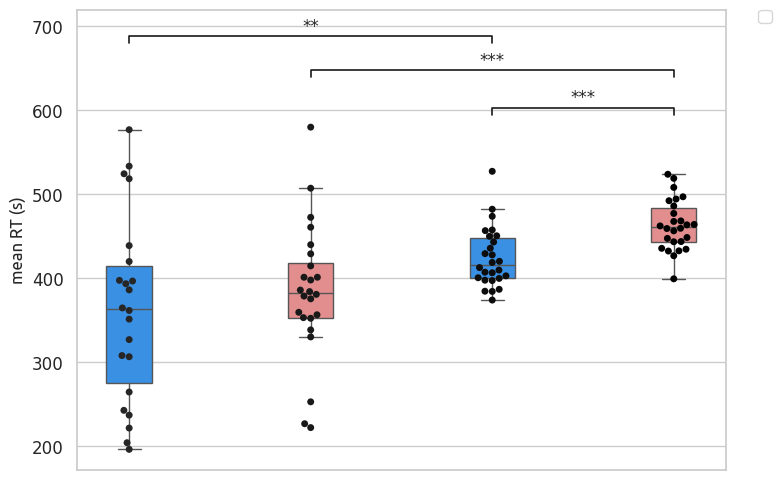

In [10]:
# RT VERSION CON BLOQUES
data = {
    'Direction': np.concatenate([
        ['Prosaccade']*len(df_blocks_filtered),
        ['Antisaccade']*len(df_blocks_filtered),
        ['Prosaccade']*len(df_blocks_filtered),
        ['Antisaccade']*len(df_blocks_filtered),
    ]),
    'Response': np.concatenate([
        ['Incorrect']*len(df_blocks_filtered),
        ['Incorrect']*len(df_blocks_filtered),
        ['Correct']*len(df_blocks_filtered),
        ['Correct']*len(df_blocks_filtered),
    ]),
    'RT': np.concatenate([
        df_blocks_filtered["pro_sacc_errors_rt_median"],
        df_blocks_filtered["anti_sacc_errors_rt_median"],
        df_blocks_filtered["pro_sacc_correct_rt_median"],
        df_blocks_filtered["anti_sacc_correct_rt_median"],
    ])
}
df_plot = pd.DataFrame(data)
df_plot['Condition'] = df_plot['Direction'] + '_' + df_plot['Response']

plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")

palette = {'Prosaccade_Incorrect': (30/255, 144/255, 255/255, 0.2),
           'Antisaccade_Incorrect': (240/255, 128/255, 128/255, 0.2),
           'Prosaccade_Correct': (30/255, 144/255, 255/255, 0.2),
           'Antisaccade_Correct': (240/255, 128/255, 128/255, 0.2)}

ax = sns.boxplot(x='Condition', y='RT', hue='Condition', data=df_plot,
    width=0.25,
    fliersize=0,
    palette=palette,
)

ax = sns.swarmplot(x='Condition', y='RT', hue='Condition', data=df_plot,
    color='black',
    size=5,
    legend=False,
)

# Significance brackets
# Condition x-positions: 0=Pro_Inc, 1=Anti_Inc, 2=Pro_Cor, 3=Anti_Cor
def sig_bracket(ax, x1, x2, y, p, lw=1.2, h=8):
    label = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=lw, c='k')
    ax.text((x1 + x2) / 2, y + h + 1, label, ha='center', va='bottom', fontsize=12)

pro_cor  = df_blocks_filtered["pro_sacc_correct_rt_median"].dropna()
anti_cor = df_blocks_filtered["anti_sacc_correct_rt_median"].dropna()
pro_inc  = df_blocks_filtered["pro_sacc_errors_rt_median"].dropna()
anti_inc = df_blocks_filtered["anti_sacc_errors_rt_median"].dropna()

_, p_cor   = ranksums(pro_cor, anti_cor)        # Pro correct vs Anti correct (2 vs 3)
_, p_ainc  = ranksums(anti_inc, anti_cor)       # Anti incorrect vs Anti correct (1 vs 3)
_, p_pinc  = ranksums(pro_inc, pro_cor)         # Pro incorrect vs Pro correct (0 vs 2)

ymax = max(pro_inc.max(), anti_inc.max(), pro_cor.max(), anti_cor.max())
sig_bracket(ax, 2, 3, ymax + 15,  p_cor)
sig_bracket(ax, 1, 3, ymax + 60,  p_ainc)
sig_bracket(ax, 0, 2, ymax + 100, p_pinc)
ax.set_ylim(top=ymax + 140)

plt.xlabel("")
plt.xticks([])
plt.ylabel("mean RT (s)", fontsize=12, font='Ubuntu')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

In [11]:
rt_lm = ols('RT ~ Direction*Response',data=df_plot).fit()
table = sm.stats.anova_lm(rt_lm, typ=2) # Type 2 ANOVA DataFrame
print(table)

                           sum_sq    df          F    PR(>F)
Direction            22690.974582   1.0   4.598949  0.034571
Response            123730.665790   1.0  25.077416  0.000003
Direction:Response    1898.442690   1.0   0.384772  0.536562
Residual            463791.108907  94.0        NaN       NaN


In [12]:
df_blocks_filtered[
        [
            "pro_sacc_errors_rt_median",
            "anti_sacc_errors_rt_median",
            "pro_sacc_correct_rt_median",
            "anti_sacc_correct_rt_median",
        ]
    ].describe()

,pro_sacc_errors_rt_median,anti_sacc_errors_rt_median,pro_sacc_correct_rt_median,anti_sacc_correct_rt_median
count,22.000000,24.000000,26.000000,26.000000
mean,362.386326,383.460538,424.574231,463.295785
std,110.981610,80.966569,35.570188,30.150567
min,196.265000,222.180000,374.085000,399.388750
25%,275.068750,352.956563,400.060000,443.581875
50%,363.222500,382.520833,415.817500,461.001875
75%,414.385000,418.386250,448.299583,483.926250
max,577.005000,580.055000,527.448333,523.926667


### Figure 3 — Anti-saccades performance (replication)

Panel A: one representative subject, anti-saccade trials in pixels (I), degrees (II) and normalized (III).
Panels B/C: error rates and RTs using all data. Panels D/E: same but using only first half (blocks 2-8).

Representative subject: ses-126 (anti err 5.0% vs cohort median 5.3%)


/tmp/ipykernel_27391/783301000.py:148: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axB.set_xticklabels(["prosaccade", "antisaccade"])
/tmp/ipykernel_27391/783301000.py:158: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axC.set_xticklabels(["Prosaccade\nincorrect", "Antisaccade\nincorrect",
/tmp/ipykernel_27391/783301000.py:168: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axD.set_xticklabels(["prosaccade", "antisaccade"])
/tmp/ipykernel_27391/783301000.py:178: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axE.set_xticklabels(["Prosaccade\nincorrect", "Antisaccade\nincorrect",


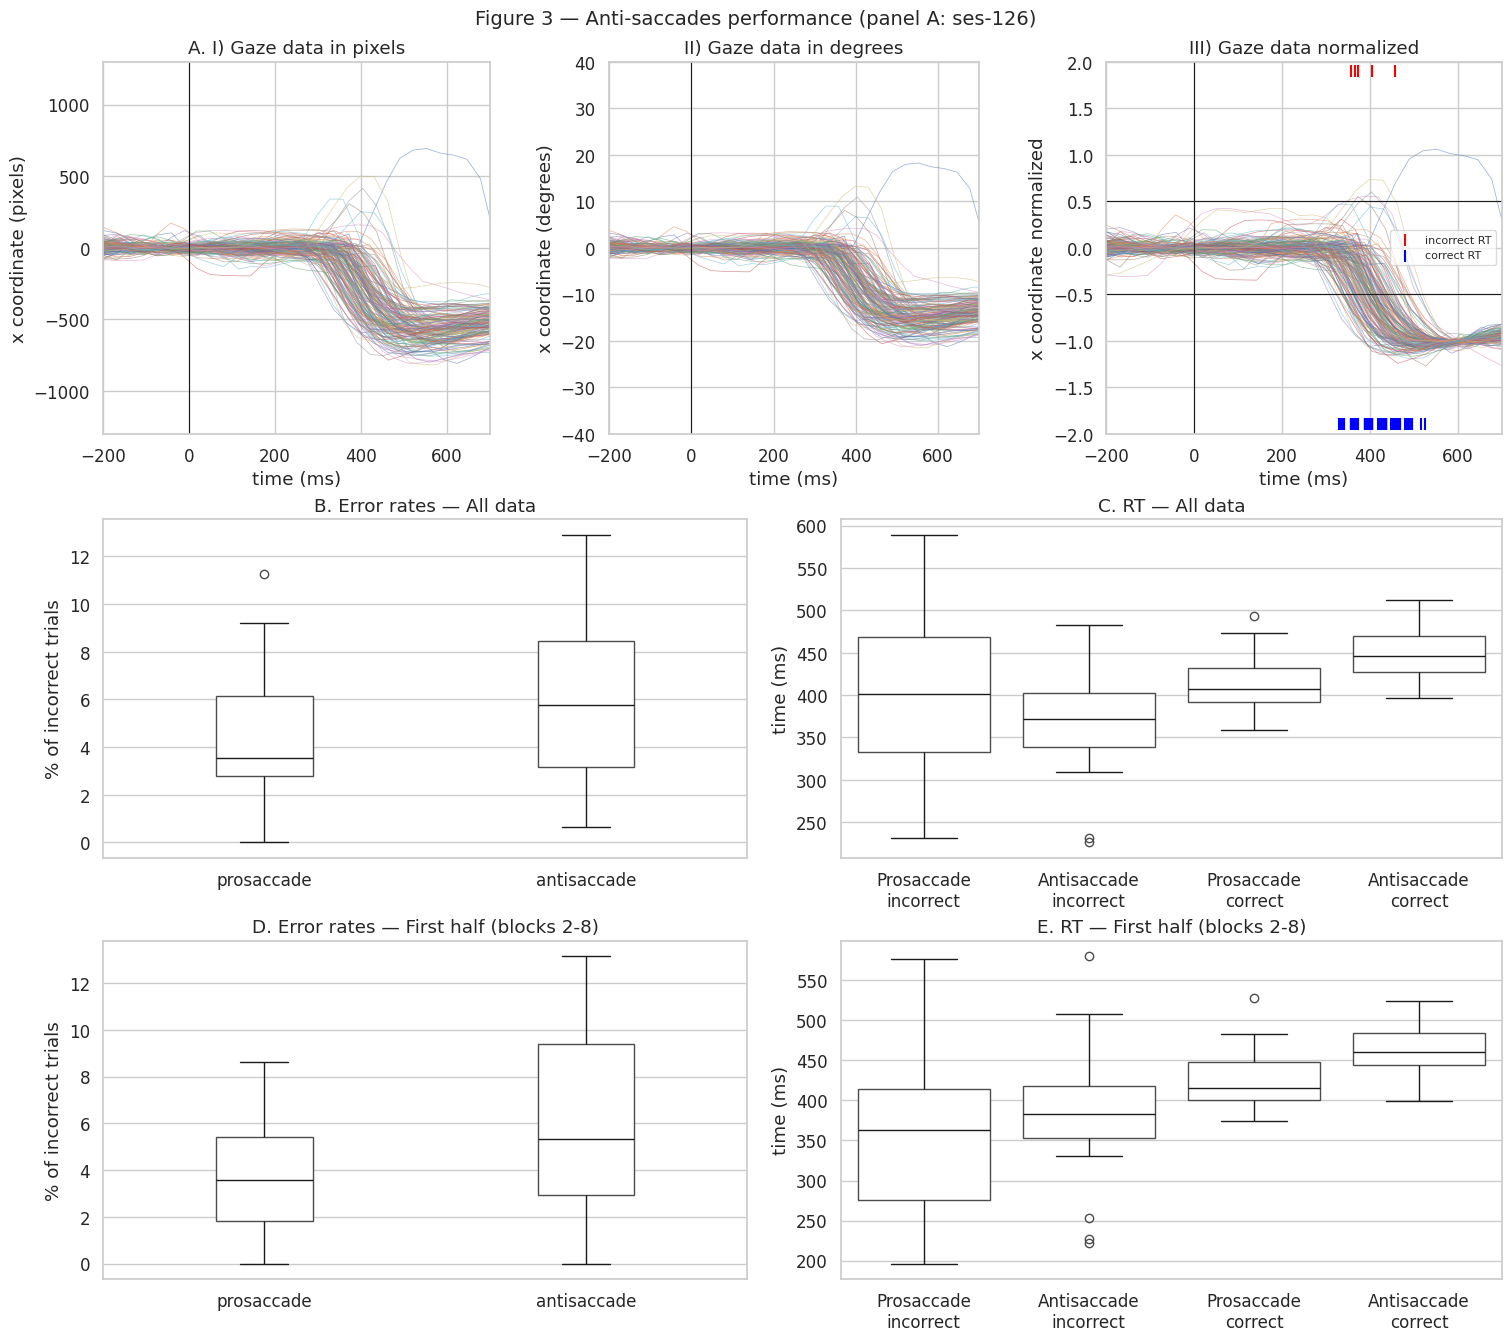


=== All data (N=26) ===
  Errors pro vs anti                 : p = 0.08705
  RT correct pro vs anti             : p = 0.0002905
  RT anti: incorrect vs correct      : p = 1.952e-06
  RT incorrect anti vs correct pro   : p = 0.003029
  RT incorrect pro vs incorrect anti : p = 0.2427

=== First half (N=26) ===
  Errors pro vs anti                 : p = 0.06067
  RT correct pro vs anti             : p = 0.0001409
  RT anti: incorrect vs correct      : p = 1.775e-05


In [13]:
# ---- Figure 3 replication ----

# 1) px2deg lookup from raw CSVs (one value per subject)
px2deg_by_subj = {}
for csv_file in sorted(RAW_DATA.glob("antisacadas_*.csv")):
    suj = csv_file.stem.split("_")[1]
    px2deg_by_subj[suj] = float(pd.read_csv(csv_file, usecols=["px2deg"])["px2deg"].dropna().iloc[0])

# 2) Preprocessing that keeps three views (pixels, degrees, normalized) for one subject
def preprocess_three_views(df_samples, px2deg, type_of_saccade="antisaccade",
                           baseline_start=-200.0, baseline_end=100.0, FILTER=1.5):
    meta_cols = ["trial_index", "typeOfSaccade", "cueShownAtLeft", "intraEnd", "isTutorial"]
    all_trials = (
        df_samples[(df_samples["isTutorial"] == False) & (df_samples["typeOfSaccade"].notna())][meta_cols]
        .drop_duplicates("trial_index").sort_values("trial_index").reset_index(drop=True)
    )
    blocks = sum([[i] * 20 for i in range(1, 17)], [])
    all_trials["block"] = blocks
    df_sacc = all_trials[all_trials["typeOfSaccade"] == type_of_saccade]

    pix, deg, norm = [], [], []
    rt_correct, rt_error = [], []

    for _, tr in df_sacc.iterrows():
        t0 = tr["intraEnd"]
        t_samps = df_samples[df_samples["trial_index"] == tr["trial_index"]].sort_values("tSample")
        xs = t_samps["X"].to_numpy(dtype=float)
        ts = t_samps["tSample"].to_numpy(dtype=float) - t0
        if len(ts) < 4 or ts[-1] <= -200:
            continue
        # interpolate at ~30 Hz (same as the rest of the notebook)
        fx = interp1d(ts, xs, kind="linear")
        samples = int((ts[-1] - (-200)) / 30)
        ts_new = np.linspace(-200, ts[-1], samples)
        xs = fx(ts_new); ts = ts_new

        x_base = np.median(xs[(ts > baseline_start) & (ts < baseline_end)])
        x_max  = np.median(xs[(ts > 500.0) & (ts <= 700.0)])
        if not np.isfinite(x_base) or not np.isfinite(x_max) or x_base == x_max:
            continue

        xs_norm = (xs - x_base) / np.abs(x_base - x_max)
        xs_pix  =  xs - x_base
        xs_deg  = (xs - x_base) / px2deg

        if tr["cueShownAtLeft"]:
            xs_norm, xs_pix, xs_deg = -xs_norm, -xs_pix, -xs_deg

        if (xs_norm >  FILTER).any() or (xs_norm < -FILTER).any():
            continue

        pix.append((ts, xs_pix))
        deg.append((ts, xs_deg))
        norm.append((ts, xs_norm))

        xs_after = xs_norm[ts > baseline_end]
        ts_after = ts[ts > baseline_end]
        if type_of_saccade == "antisaccade":
            err_idx = np.where(xs_after >  0.5)[0]
            cor_idx = np.where(xs_after < -0.5)[0]
        else:
            err_idx = np.where(xs_after < -0.5)[0]
            cor_idx = np.where(xs_after >  0.5)[0]
        if len(err_idx):
            rt_error.append(float(ts_after[err_idx[0]]))
        elif len(cor_idx):
            rt_correct.append(float(ts_after[cor_idx[0]]))

    return {"pixels": pix, "degrees": deg, "normalized": norm,
            "rt_correct": rt_correct, "rt_error": rt_error}

# 3) Pick representative subject: closest to cohort median antisaccade error rate, with enough clean trials
_med = df_blocks_filtered["antisaccade_errors_perc"].median()
_cands = df_blocks_filtered.copy()
_cands = _cands[_cands["antisaccade_trials_remained"] >= 80]
_cands["dist"] = (_cands["antisaccade_errors_perc"] - _med).abs()
rep_subj = _cands.sort_values("dist").index[0]
print(f"Representative subject: ses-{rep_subj} "
      f"(anti err {_cands.loc[rep_subj, 'antisaccade_errors_perc']:.1f}% vs cohort median {_med:.1f}%)")

samples_file = derivatives_path / "sub-0001" / f"ses-{rep_subj}" / "samples.feather"
df_samples_rep = feather.read_feather(samples_file)
views = preprocess_three_views(df_samples_rep, px2deg_by_subj[rep_subj])

# 4) All-data aggregation (no first-half filter; same per-block max 50% error filter)
df_alldata = (
    df_all_blocks.query("prosaccade_errors < @MAX_NUMBER_INCORRECTS_BY_BLOCK and "
                        "antisaccade_errors < @MAX_NUMBER_INCORRECTS_BY_BLOCK")
    .groupby("subject").agg({
        "prosaccade_errors": "sum", "antisaccade_errors": "sum",
        "prosaccade_trials_remained": "sum", "antisaccade_trials_remained": "sum",
        "pro_sacc_errors_rt_median":  np.nanmean,
        "anti_sacc_errors_rt_median": np.nanmean,
        "pro_sacc_correct_rt_median": np.nanmean,
        "anti_sacc_correct_rt_median": np.nanmean,
    })
)
df_alldata["prosaccade_errors_perc"]  = df_alldata["prosaccade_errors"]  / df_alldata["prosaccade_trials_remained"]  * 100
df_alldata["antisaccade_errors_perc"] = df_alldata["antisaccade_errors"] / df_alldata["antisaccade_trials_remained"] * 100

# 5) Compose the figure
fig = plt.figure(figsize=(15, 13), constrained_layout=True)
gs = fig.add_gridspec(3, 6, height_ratios=[1.1, 1, 1])

def _plot_traces(ax, traces, ylabel, threshold=None, ylim=None, title=None):
    for ts, xs in traces:
        ax.plot(ts, xs, lw=0.5, alpha=0.6)
    ax.axvline(0, color="k", lw=0.8)
    if threshold is not None:
        ax.axhline( threshold, color="k", lw=0.8)
        ax.axhline(-threshold, color="k", lw=0.8)
    ax.set_xlim(-200, 700)
    if ylim: ax.set_ylim(*ylim)
    ax.set_xlabel("time (ms)")
    ax.set_ylabel(ylabel)
    if title: ax.set_title(title)

axA1 = fig.add_subplot(gs[0, 0:2])
_plot_traces(axA1, views["pixels"], "x coordinate (pixels)",
             ylim=(-1300, 1300), title="A. I) Gaze data in pixels")

axA2 = fig.add_subplot(gs[0, 2:4])
_plot_traces(axA2, views["degrees"], "x coordinate (degrees)",
             ylim=(-40, 40), title="II) Gaze data in degrees")

axA3 = fig.add_subplot(gs[0, 4:6])
_plot_traces(axA3, views["normalized"], "x coordinate normalized",
             threshold=0.5, ylim=(-2, 2), title="III) Gaze data normalized")
# Adjacent RT histograms (paper: incorrect on top, correct on bottom for anti-saccade)
if views["rt_error"]:
    axA3.scatter(views["rt_error"], [1.9]*len(views["rt_error"]),
                 marker="|", color="red",  s=80, label="incorrect RT")
if views["rt_correct"]:
    axA3.scatter(views["rt_correct"], [-1.9]*len(views["rt_correct"]),
                 marker="|", color="blue", s=80, label="correct RT")
axA3.legend(loc="center right", fontsize=8, framealpha=0.7)

def _white_box(ax):
    for box in ax.patches: box.set_facecolor("w")
    plt.setp(ax.artists, edgecolor="k", facecolor="w")
    plt.setp(ax.lines, color="k")

# Panel B — all data error rates
axB = fig.add_subplot(gs[1, 0:3])
sns.boxplot(data=df_alldata[["prosaccade_errors_perc", "antisaccade_errors_perc"]],
            ax=axB, width=0.3)
_white_box(axB)
axB.set_xticklabels(["prosaccade", "antisaccade"])
axB.set_ylabel("% of incorrect trials")
axB.set_title("B. Error rates — All data")

# Panel C — all data RTs
axC = fig.add_subplot(gs[1, 3:6])
sns.boxplot(data=df_alldata[["pro_sacc_errors_rt_median", "anti_sacc_errors_rt_median",
                              "pro_sacc_correct_rt_median", "anti_sacc_correct_rt_median"]],
            ax=axC)
_white_box(axC)
axC.set_xticklabels(["Prosaccade\nincorrect", "Antisaccade\nincorrect",
                     "Prosaccade\ncorrect",   "Antisaccade\ncorrect"])
axC.set_ylabel("time (ms)")
axC.set_title("C. RT — All data")

# Panel D — first half error rates
axD = fig.add_subplot(gs[2, 0:3])
sns.boxplot(data=df_blocks_filtered[["prosaccade_errors_perc", "antisaccade_errors_perc"]],
            ax=axD, width=0.3)
_white_box(axD)
axD.set_xticklabels(["prosaccade", "antisaccade"])
axD.set_ylabel("% of incorrect trials")
axD.set_title("D. Error rates — First half (blocks 2-8)")

# Panel E — first half RTs
axE = fig.add_subplot(gs[2, 3:6])
sns.boxplot(data=df_blocks_filtered[["pro_sacc_errors_rt_median", "anti_sacc_errors_rt_median",
                                      "pro_sacc_correct_rt_median", "anti_sacc_correct_rt_median"]],
            ax=axE)
_white_box(axE)
axE.set_xticklabels(["Prosaccade\nincorrect", "Antisaccade\nincorrect",
                     "Prosaccade\ncorrect",   "Antisaccade\ncorrect"])
axE.set_ylabel("time (ms)")
axE.set_title("E. RT — First half (blocks 2-8)")

fig.suptitle(f"Figure 3 — Anti-saccades performance (panel A: ses-{rep_subj})", fontsize=14, y=1.02)

Path("result_plots").mkdir(exist_ok=True)
plt.savefig("result_plots/figure3.png", dpi=150, bbox_inches="tight")
plt.show()

# 6) Stats — Wilcoxon rank-sum, matching paper Tests
def _ranksum(a, b):
    a = np.asarray(a); b = np.asarray(b)
    a = a[np.isfinite(a)]; b = b[np.isfinite(b)]
    return ranksums(a, b)[1]

print("\n=== All data (N=", len(df_alldata), ") ===", sep="")
print(f"  Errors pro vs anti                 : p = {_ranksum(df_alldata.prosaccade_errors_perc, df_alldata.antisaccade_errors_perc):.4g}")
print(f"  RT correct pro vs anti             : p = {_ranksum(df_alldata.pro_sacc_correct_rt_median, df_alldata.anti_sacc_correct_rt_median):.4g}")
print(f"  RT anti: incorrect vs correct      : p = {_ranksum(df_alldata.anti_sacc_errors_rt_median, df_alldata.anti_sacc_correct_rt_median):.4g}")
print(f"  RT incorrect anti vs correct pro   : p = {_ranksum(df_alldata.anti_sacc_errors_rt_median, df_alldata.pro_sacc_correct_rt_median):.4g}")
print(f"  RT incorrect pro vs incorrect anti : p = {_ranksum(df_alldata.pro_sacc_errors_rt_median, df_alldata.anti_sacc_errors_rt_median):.4g}")

print("\n=== First half (N=", len(df_blocks_filtered), ") ===", sep="")
print(f"  Errors pro vs anti                 : p = {_ranksum(df_blocks_filtered.prosaccade_errors_perc, df_blocks_filtered.antisaccade_errors_perc):.4g}")
print(f"  RT correct pro vs anti             : p = {_ranksum(df_blocks_filtered.pro_sacc_correct_rt_median, df_blocks_filtered.anti_sacc_correct_rt_median):.4g}")
print(f"  RT anti: incorrect vs correct      : p = {_ranksum(df_blocks_filtered.anti_sacc_errors_rt_median, df_blocks_filtered.anti_sacc_correct_rt_median):.4g}")
